<a href="https://colab.research.google.com/github/Kemal1101/Model-Comparison-for-Sistem-Tes-Minat-Career/blob/main/Perbandingan_Metode_Perankingan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Membaca dataset...
Dataset berhasil diload!

=== MATRIKS KEPUTUSAN AWAL (X) ===
                                  Alternatif_Profesi  C1_Nilai_CF  \
0                   Quality Control Systems Managers         0.80   
1  Drilling and Boring Machine Tool Setters, Oper...         0.86   
2                           Investment Fund Managers         0.80   
3    First-Line Supervisors of Correctional Officers         0.81   
4                                    Cost Estimators         0.80   

   C2_Kesesuaian_Keyword  
0                   60.8  
1                   58.6  
2                   89.5  
3                   73.4  
4                   53.4  
--------------------------------------------------

=== HASIL KEPUTUSAN METODE SAW ===
                                  Alternatif_Profesi   Norm_C1   Norm_C2  \
0                           Investment Fund Manager

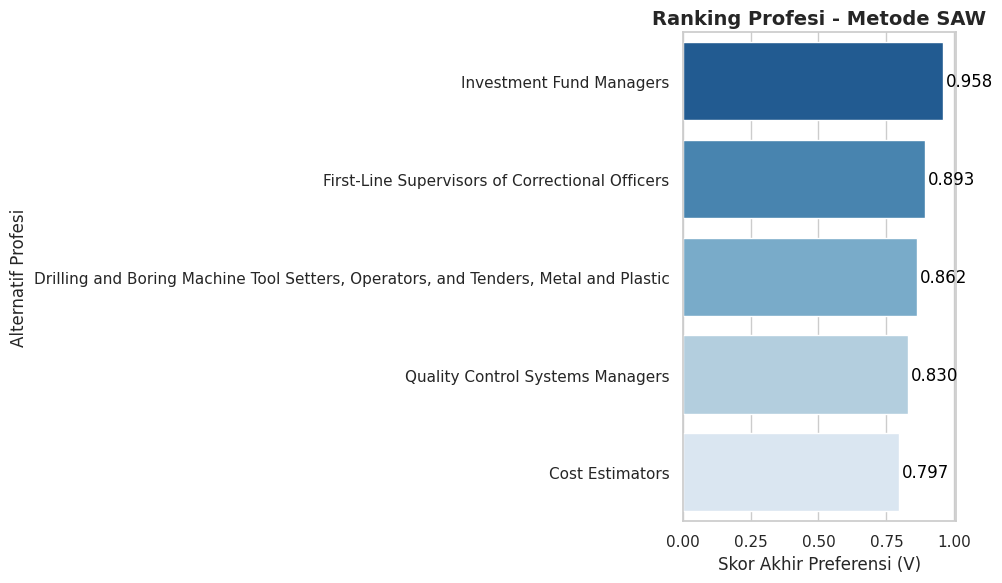

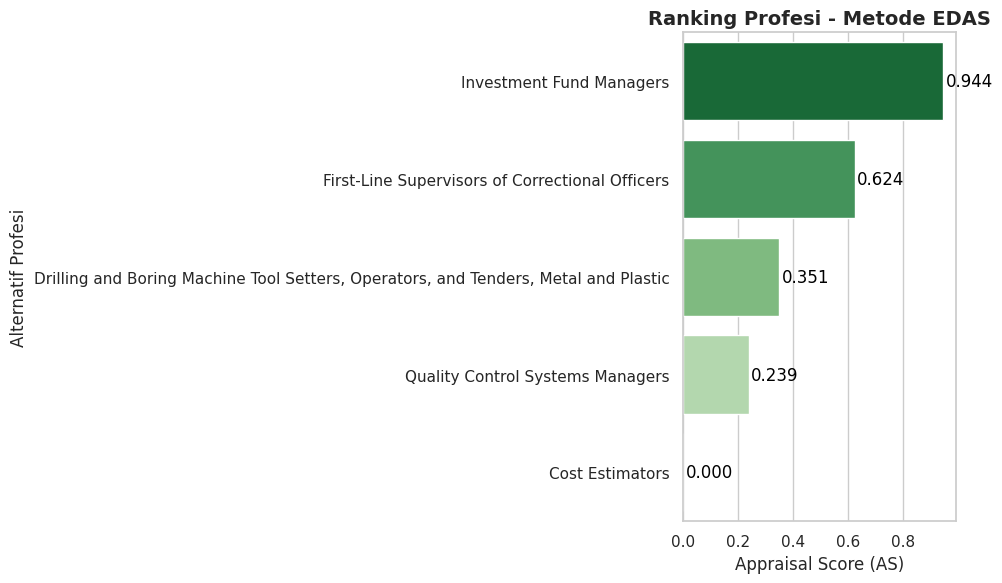

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. MOUNT GOOGLE DRIVE
# Uncomment baris di bawah jika dataset berada di Google Drive
drive.mount('/content/drive')
path_riasec = '/content/drive/MyDrive/Kuis_SBP/Preprocessed_RIASEC_Dataset.csv'
path_questions = '/content/drive/MyDrive/Kuis_SBP/questions_rows.csv'
path_onet = '/content/drive/MyDrive/Kuis_SBP/Onet_Top3_Occupations_by_InterestCode.xlsx'

# 2. LOAD DATASET
print("Membaca dataset...")
try:
    df_riasec = pd.read_csv(path_riasec)
    df_questions = pd.read_csv(path_questions)
    xls_onet = pd.ExcelFile(path_onet)
    df_onet = pd.read_excel(xls_onet, sheet_name=xls_onet.sheet_names[0])
    print("Dataset berhasil diload!\n")
except Exception as e:
    print("Error loading data:", e)

# 3. PEMBENTUKAN MATRIKS KEPUTUSAN (Simulasi Fase 1 & 2)
# Misalkan User memiliki Holland Code dominan dan kita mem-filter 5 profesi teratas
np.random.seed(42) # Agar hasil random tetap konsisten untuk pembelajaran
sample_occupations = df_onet.sample(5)['Occupation'].values

# Mensimulasikan hasil dari Fase 1 (Mesin Inferensi CF) & Kecocokan Keyword
# C1: Total Nilai CF Profesi (Skala 0 - 1)
# C2: Kesesuaian Keyword (Skala 0 - 100%)
data_keputusan = {
    'Alternatif_Profesi': sample_occupations,
    'C1_Nilai_CF': np.round(np.random.uniform(0.6, 0.95, 5), 2),
    'C2_Kesesuaian_Keyword': np.round(np.random.uniform(40, 95, 5), 1)
}

df_decision = pd.DataFrame(data_keputusan)
print("=== MATRIKS KEPUTUSAN AWAL (X) ===")
print(df_decision)
print("-" * 50)

# Inisialisasi Bobot (Sesuai Dokumen SKPL/RPP)
# W1 = 60% (CF), W2 = 40% (Keyword). Kedua kriteria adalah BENEFIT.
W = np.array([0.60, 0.40])

# ==========================================
# 4. PROSES METODE SAW
# ==========================================
df_saw = df_decision.copy()

# Tahap Normalisasi (Benefit: Nilai / Max Nilai)
df_saw['Norm_C1'] = df_saw['C1_Nilai_CF'] / df_saw['C1_Nilai_CF'].max()
df_saw['Norm_C2'] = df_saw['C2_Kesesuaian_Keyword'] / df_saw['C2_Kesesuaian_Keyword'].max()

# Tahap Preferensi (V)
df_saw['Skor_Akhir_SAW'] = (df_saw['Norm_C1'] * W[0]) + (df_saw['Norm_C2'] * W[1])
df_saw = df_saw.sort_values(by='Skor_Akhir_SAW', ascending=False).reset_index(drop=True)

print("\n=== HASIL KEPUTUSAN METODE SAW ===")
print(df_saw[['Alternatif_Profesi', 'Norm_C1', 'Norm_C2', 'Skor_Akhir_SAW']])

# ==========================================
# 5. PROSES METODE EDAS
# ==========================================
df_edas = df_decision.copy()

# Hitung Average Solution (AV)
AV_C1 = df_edas['C1_Nilai_CF'].mean()
AV_C2 = df_edas['C2_Kesesuaian_Keyword'].mean()

# Hitung PDA (Positive Distance) dan NDA (Negative Distance) karena kriteria Benefit
# PDA = max(0, (X - AV) / AV)
# NDA = max(0, (AV - X) / AV)
df_edas['PDA_C1'] = np.maximum(0, (df_edas['C1_Nilai_CF'] - AV_C1) / AV_C1)
df_edas['PDA_C2'] = np.maximum(0, (df_edas['C2_Kesesuaian_Keyword'] - AV_C2) / AV_C2)

df_edas['NDA_C1'] = np.maximum(0, (AV_C1 - df_edas['C1_Nilai_CF']) / AV_C1)
df_edas['NDA_C2'] = np.maximum(0, (AV_C2 - df_edas['C2_Kesesuaian_Keyword']) / AV_C2)

# Hitung SP (Sum of PDA) dan SN (Sum of NDA) berbobot
df_edas['SP'] = (df_edas['PDA_C1'] * W[0]) + (df_edas['PDA_C2'] * W[1])
df_edas['SN'] = (df_edas['NDA_C1'] * W[0]) + (df_edas['NDA_C2'] * W[1])

# Normalisasi SP dan SN
max_SP = df_edas['SP'].max()
max_SN = df_edas['SN'].max()

df_edas['NSP'] = df_edas['SP'] / max_SP if max_SP != 0 else 0
df_edas['NSN'] = 1 - (df_edas['SN'] / max_SN) if max_SN != 0 else 0

# Hitung Appraisal Score (AS)
df_edas['Skor_Akhir_EDAS'] = 0.5 * (df_edas['NSP'] + df_edas['NSN'])
df_edas = df_edas.sort_values(by='Skor_Akhir_EDAS', ascending=False).reset_index(drop=True)

print("\n=== HASIL KEPUTUSAN METODE EDAS ===")
print(df_edas[['Alternatif_Profesi', 'SP', 'SN', 'Skor_Akhir_EDAS']])


# ==========================================
# 6. VISUALISASI PERBANDINGAN (Dua Gambar Berbeda)
# ==========================================
sns.set_theme(style="whitegrid")

# GAMBAR 1: SAW
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Skor_Akhir_SAW',
    y='Alternatif_Profesi',
    data=df_saw,
    hue='Alternatif_Profesi',
    palette='Blues_r',
    legend=False
)
plt.title('Ranking Profesi - Metode SAW', fontsize=14, fontweight='bold')
plt.xlabel('Skor Akhir Preferensi (V)')
plt.ylabel('Alternatif Profesi')
for i, v in enumerate(df_saw['Skor_Akhir_SAW']):
    plt.text(v + 0.01, i, f"{v:.3f}", color='black', va='center')
plt.tight_layout()
plt.show()

# GAMBAR 2: EDAS
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Skor_Akhir_EDAS',
    y='Alternatif_Profesi',
    data=df_edas,
    hue='Alternatif_Profesi',
    palette='Greens_r',
    legend=False
)
plt.title('Ranking Profesi - Metode EDAS', fontsize=14, fontweight='bold')
plt.xlabel('Appraisal Score (AS)')
plt.ylabel('Alternatif Profesi')
for i, v in enumerate(df_edas['Skor_Akhir_EDAS']):
    plt.text(v + 0.01, i, f"{v:.3f}", color='black', va='center')
plt.tight_layout()
plt.show()

=== MATRIKS KEPUTUSAN AWAL (X) ===
                                  Alternatif_Profesi  C1_Nilai_CF  \
0                   Quality Control Systems Managers         0.80   
1  Drilling and Boring Machine Tool Setters, Oper...         0.86   
2                           Investment Fund Managers         0.80   
3    First-Line Supervisors of Correctional Officers         0.81   
4                                    Cost Estimators         0.80   

   C2_Kesesuaian_Keyword  
0                   60.8  
1                   58.6  
2                   89.5  
3                   73.4  
4                   53.4  
--------------------------------------------------

=== HASIL KEPUTUSAN METODE TOPSIS ===
                                  Alternatif_Profesi    D_plus     D_min  \
0                           Investment Fund Managers  0.019770  0.094438   
1    First-Line Supervisors of Correctional Officers  0.045225  0.052424   
2  Drilling and Boring Machine Tool Setters, Oper...  0.080834  0.0239

/tmp/ipykernel_8143/2318626590.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


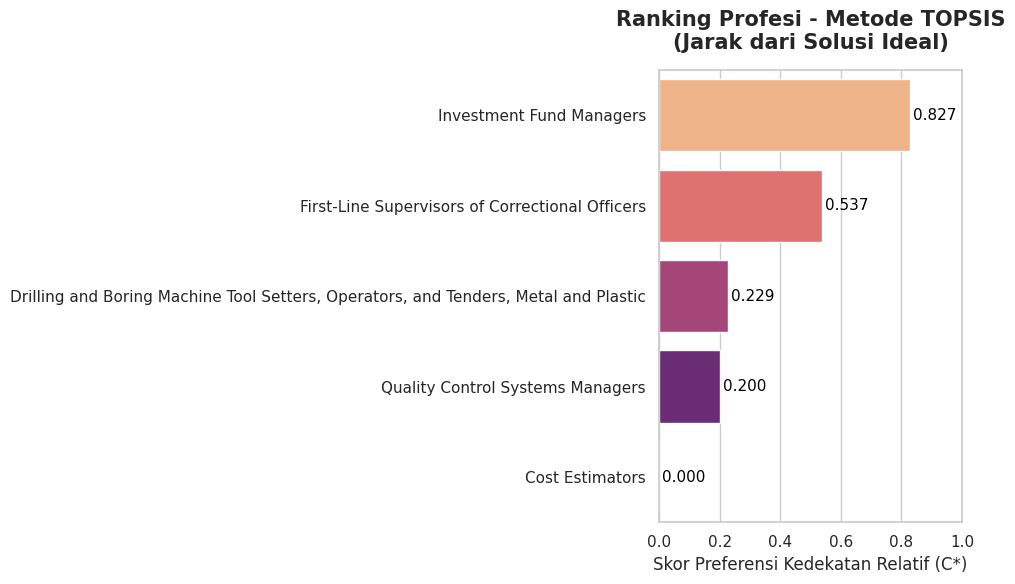

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. MATRIKS KEPUTUSAN AWAL (Data Persis Sama)
# ==========================================
data_keputusan = {
    'Alternatif_Profesi': [
        'Quality Control Systems Managers',
        'Drilling and Boring Machine Tool Setters, Operators, and Tenders, Metal and Plastic',
        'Investment Fund Managers',
        'First-Line Supervisors of Correctional Officers',
        'Cost Estimators'
    ],
    'C1_Nilai_CF': [0.80, 0.86, 0.80, 0.81, 0.80],
    'C2_Kesesuaian_Keyword': [60.8, 58.6, 89.5, 73.4, 53.4]
}
df_topsis = pd.DataFrame(data_keputusan)
W = np.array([0.60, 0.40]) # Bobot: CF (60%), Keyword (40%)

print("=== MATRIKS KEPUTUSAN AWAL (X) ===")
print(df_topsis)
print("-" * 50)

# ==========================================
# 2. PROSES METODE TOPSIS
# ==========================================
# Langkah 1: Matriks Keputusan Ternormalisasi (R)
# Normalisasi TOPSIS membagi nilai dengan akar dari jumlah kuadrat setiap kolom
pembagi_C1 = np.sqrt((df_topsis['C1_Nilai_CF']**2).sum())
pembagi_C2 = np.sqrt((df_topsis['C2_Kesesuaian_Keyword']**2).sum())

df_topsis['Norm_C1'] = df_topsis['C1_Nilai_CF'] / pembagi_C1
df_topsis['Norm_C2'] = df_topsis['C2_Kesesuaian_Keyword'] / pembagi_C2

# Langkah 2: Matriks Keputusan Ternormalisasi Berbobot (Y)
df_topsis['Y_C1'] = df_topsis['Norm_C1'] * W[0]
df_topsis['Y_C2'] = df_topsis['Norm_C2'] * W[1]

# Langkah 3: Menentukan Solusi Ideal Positif (A+) dan Negatif (A-)
# Karena kedua kriteria adalah BENEFIT, maka A+ adalah nilai Max, A- adalah nilai Min
A_plus = [df_topsis['Y_C1'].max(), df_topsis['Y_C2'].max()]
A_min = [df_topsis['Y_C1'].min(), df_topsis['Y_C2'].min()]

# Langkah 4: Menghitung Jarak Solusi Ideal (D+ dan D-)
# Jarak euclidean dari masing-masing alternatif ke A+ dan A-
df_topsis['D_plus'] = np.sqrt((df_topsis['Y_C1'] - A_plus[0])**2 + (df_topsis['Y_C2'] - A_plus[1])**2)
df_topsis['D_min'] = np.sqrt((df_topsis['Y_C1'] - A_min[0])**2 + (df_topsis['Y_C2'] - A_min[1])**2)

# Langkah 5: Menghitung Nilai Preferensi / Kedekatan Relatif (V / C*)
# Rumus: D- / (D+ + D-)
df_topsis['Skor_Akhir_TOPSIS'] = df_topsis['D_min'] / (df_topsis['D_plus'] + df_topsis['D_min'])

# Mengurutkan Peringkat
df_topsis_ranked = df_topsis.sort_values(by='Skor_Akhir_TOPSIS', ascending=False).reset_index(drop=True)

print("\n=== HASIL KEPUTUSAN METODE TOPSIS ===")
print(df_topsis_ranked[['Alternatif_Profesi', 'D_plus', 'D_min', 'Skor_Akhir_TOPSIS']])

# ==========================================
# 3. VISUALISASI HASIL TOPSIS
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot Bar Chart
ax = sns.barplot(
    x='Skor_Akhir_TOPSIS',
    y='Alternatif_Profesi',
    data=df_topsis_ranked,
    palette='magma_r' # Warna yang elegan untuk menunjukkan gradasi
)

plt.title('Ranking Profesi - Metode TOPSIS\n(Jarak dari Solusi Ideal)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Skor Preferensi Kedekatan Relatif (C*)')
plt.ylabel('')

# Menambahkan label angka di sebelah kanan bar
for i, v in enumerate(df_topsis_ranked['Skor_Akhir_TOPSIS']):
    ax.text(v + 0.01, i, f"{v:.3f}", color='black', va='center', fontsize=11)

plt.xlim(0, 1)
plt.tight_layout()
plt.show()